In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
sampled_latent_paths = pd.read_csv("sampled_paths.csv",header = None)

In [7]:
true_v = pd.read_csv("v_path.csv", header=None)

In [8]:
samples = sampled_latent_paths.values
adaptive_mean = samples.mean(axis=0)
adaptive_std = samples.std(axis=0)

# Option A: empirical 95% credible interval
lower = np.quantile(samples, 0.025, axis=0)
upper = np.quantile(samples, 0.975, axis=0)

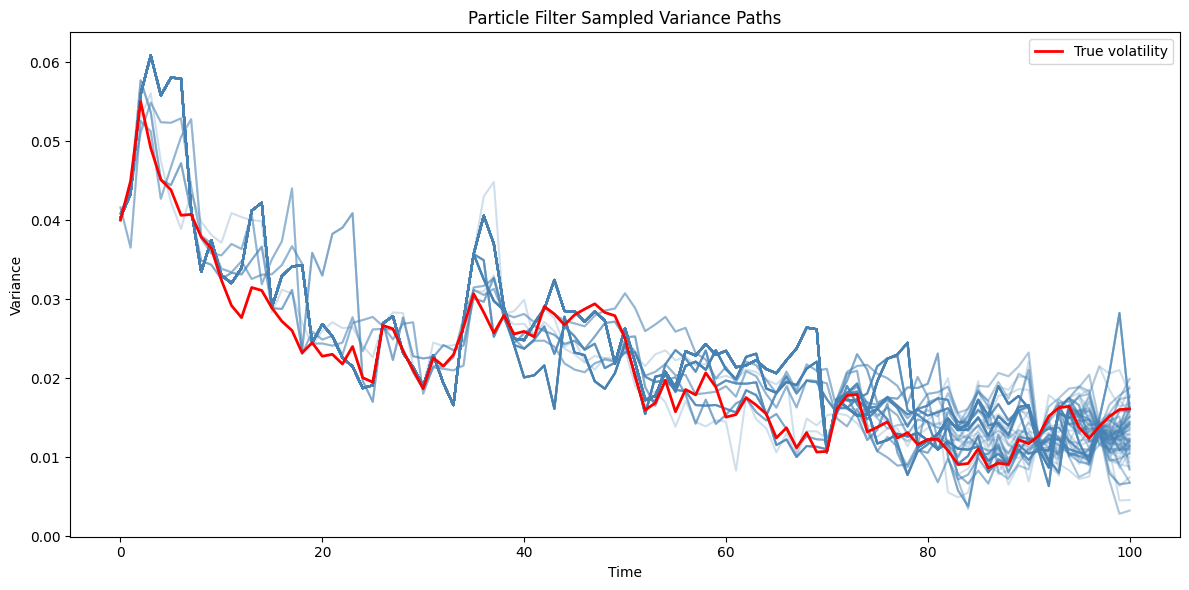

In [15]:
plt.figure(figsize=(12, 6))

# plot sampled PF paths
for path in samples:
    plt.plot(path, color="steelblue", alpha=0.25)

# plot true volatility
plt.plot(true_v.values.flatten(), color="red", linewidth=2, label="True volatility")

plt.xlabel("Time")
plt.ylabel("Variance")
plt.title("Particle Filter Sampled Variance Paths")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
samples.shape

(100, 101)

In [11]:
calibrated_params = pd.read_csv("calibrated_params.csv", header=None)
calibrated_params.shape

(2, 6)

In [12]:
#
# 0 - mu
# 1 - sigma (vol-of-vol)
# 2 - kappa
# 3 - theta
# 4 - rho
# 5 - lambda

mu = calibrated_params.iat[0,0]
sigma = calibrated_params.iat[0,1]
kappa = calibrated_params.iat[0,2]
theta = calibrated_params.iat[0,3]
rho = calibrated_params.iat[0,4]
_lambda = calibrated_params.iat[0,5]

mu_std = calibrated_params.iat[1,0]**0.5
sigma_std = calibrated_params.iat[1,1]**0.5
kappa_std = calibrated_params.iat[1,2]**0.5
theta_std = calibrated_params.iat[1,3]**0.5
rho_std = calibrated_params.iat[1,3]**0.5
lambda_std = calibrated_params.iat[1,5]**0.5

In [13]:
print(mu, kappa, theta, sigma, rho, _lambda)

0.183317 1.94278 0.0421363 0.354678 -0.725073 0.852631


In [14]:
print(mu_std, kappa_std, theta_std, sigma_std, rho_std, lambda_std)


0.33363602922945834 0.7357717037233764 0.007334650639260196 0.09568646717274079 0.007334650639260196 0.4233674526932839
